In [39]:
from fredapi import Fred
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.tsa.api import VAR
from statsmodels.api import OLS
import pandas as pd
from scipy.stats import kurtosis, skew
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


from sklearn.model_selection import train_test_split
np.random.seed(0)
import datetime as dt

In [40]:


def col_names(mats):
        return [f'{m*12:.0f}m' for m in mats]
def make_nss_yield_df(start_date= '1986-12-01', end_date = '2012-01-01', max_maturity = 120):
    df = pd.read_csv('feds200628.csv', skiprows=9)
    df = df[['Date', 'BETA0', 'BETA1', 'BETA2', 'BETA3', 'TAU1', 'TAU2']]
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.query('Date > "1980-01-01"')
    
    # Calculate the yields using the NSS formula for each maturity directly
    n_years = np.arange(1,max_maturity+1) / 12
    yields = np.empty((len(df), len(n_years)))
    for i, n in enumerate(n_years):
        term1 = (1 - np.exp(-n / df['TAU1'])) / (n / df['TAU1'])
        term2 = np.exp(-n / df['TAU1'])
        term3 = (1 - np.exp(-n / df['TAU2'])) / (n / df['TAU2'])
        term4 = np.exp(-n / df['TAU2'])
        yields[:, i] = df['BETA0'] + df['BETA1'] * term1 + df['BETA2'] * (term1 - term2) + df['BETA3'] * (term3 - term4)
    
    
    
    
    yields_df = pd.DataFrame(yields, columns=col_names(n_years), index=pd.to_datetime(df['Date']))
    yields_df = yields_df.loc[start_date:end_date].resample('BM').last() / 100
    yields_df.index = yields_df.index.to_period('M')
    return yields_df

def make_yield_df(start_date= '1986-12', end_date = '2012-01', max_maturity = 120, freq= 'monthly'):
    if freq == 'monthly':
        pure_data = pd.read_csv('yield_panel_monthly_frequency_monthly_maturity.csv', index_col=0).query(f'MAX_DATA_TTM > {max_maturity}').iloc[:,1:max_maturity+1]
    else:
        pure_data = pd.read_csv('yield_panel_daily_frequency_monthly_maturity.csv', index_col=0).query(f'MAX_DATA_TTM > {max_maturity}').iloc[:,1:max_maturity+1]
    pure_data.index = pd.to_datetime(pure_data.index)
    pure_data = pure_data.loc[start_date:end_date]
    pure_data.index = pure_data.index.to_period('M')
    return pure_data



def make_df_rx(yields_df: pd.DataFrame, rx_maturities):
    
    #display(yields_df)
    # Assuming the yield of the shortest maturity as the risk-free rate (in decimal form)
    
    # Compute log prices (-n * yield) for continuously compounded yield
    log_prices = -yields_df.values * np.arange(1, yields_df.shape[1]+1)/12
    assert sum(abs(-yields_df.values[:,2] * 0.25 - log_prices[:,2])) < 1.e-6 # assert scaling is correctly applied to data
    #log_prices = log_prices.values
    rfr_t = -log_prices[:-1,0] #       get time 0, 1,..., T-1 and maturity 1 
    p_t_n = log_prices[:-1, 1:] #     get time 0, 1,..., T-1 and maturities 2, 3,.., N. 
    p_tp1_nm1 = log_prices[1:, :-1] # get time 1, 2,..., T   and maturities 1, 2,.., N-1
    
    rx = p_tp1_nm1 - p_t_n - rfr_t.reshape(-1,1)
    rx_maturities_idx = rx_maturities - 2

    df_rx = pd.DataFrame(rx[:,rx_maturities_idx], columns = col_names(rx_maturities/12), index=yields_df.index[1:])
    
    return df_rx


from dataclasses import dataclass
def estimate_X_full_PCA(df_yields, n_components=5):
    pca_whiten = PCA(n_components=n_components, whiten=True)

    X_maturities_idx = np.arange(3, df_yields.shape[1]+1, 1)-1 # subtract due to 0-indexing
    pca_data = df_yields.iloc[:, X_maturities_idx]
    
    X_full = pca_whiten.fit_transform(pca_data)
    #print(np.mean(X_full, axis=1))
    return X_full, pca_whiten

def make_unspanned_data(start_date= '1986-12', end_date = '2012-01'):
    data = pd.read_csv('cfnai-data-series-xlsx.csv', index_col='Date')['CFNAI_MA3']
    date = pd.to_datetime(pd.read_csv('cfnai-data-series-xlsx.csv')['Date'].str.replace(':','-'))
    data.index = date
    data.index = data.index.to_period('M')
    data = data.loc[start_date:end_date]
    cpi = pd.read_csv('cpi.csv', index_col='Date')
    date = pd.to_datetime(pd.read_csv('cpi.csv')['Date'], dayfirst=True)
    cpi.index = date
    cpi.index = cpi.index.to_period('M')
    cpi = cpi.loc[start_date:end_date]
    cpi = cpi.astype(float)
    dat_full = pd.concat([data, cpi], axis=1)

    return dat_full.values








In [41]:
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy import stats

def coef_stats(X, y, model):
    # Ensure the model is fitted with X and y as suggested
    if not hasattr(model, 'coef_'):
        model.fit(X, y)
    
    # Number of observations and features
    T, K = X.shape
    N = y.shape[1]  # Number of target variables
    
    # Predict the outputs
    y_pred = model.predict(X)
    
    # Residuals
    residuals = y - y_pred
    
    # Residual sum of squares for each target
    RSS = np.sum(residuals**2, axis=0)
    
    # Mean Squared Error for each response
    MSE = RSS / (T - K - 1)
    
    # Standard Error for each coefficient across all responses
    XTX_inv = np.linalg.inv(X.T @ X)
    var_b = np.outer(np.diag(XTX_inv), MSE)
    se = np.sqrt(var_b).reshape(K, N)
    
    # T-statistics for each coefficient
    t_stats = model.coef_.T / se
    
    # P-values for each coefficient
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=T-K-1))
    print("=======================================================================")
    print("Coeff/P-Value".ljust(16), end='')
    for j in range(K):
        print(f"Param {j+1}".ljust(16), end='')
    print()
    
    # Print coefficients and p-values in a structured table
    for i in range(N):
        print(f"Response y{i+1}".ljust(16), end='')
        for j in range(K):
            star = '*' if p_values[j, i] < 0.05 else ''
            print(f"{model.coef_[i, j]:+.4f}{star}".ljust(16), end='')
        print()
        print("P-Value".ljust(16), end='')
        for j in range(K):
            print(f"{p_values[j, i]:.4f}".ljust(16), end='')
        print("\n")
    print("=======================================================================")
# Example usage:
X = np.random.rand(100, 3)  # 100 observations, 3 features
y = np.random.rand(100, 2)  # 100 observations, 2 target variables
model = LinearRegression()

coef_stats(X, y, model)


Coeff/P-Value   Param 1         Param 2         Param 3         
Response y1     -0.1822*        +0.0173         +0.0145         
P-Value         0.0431          0.8328          0.8673          

Response y2     +0.0790         +0.0526         +0.0357         
P-Value         0.3927          0.5346          0.6906          



In [42]:
from sklearn.linear_model import LinearRegression
import scipy.stats as stats
def fit_to_df(data, df, special_columns=False):
    columns = special_columns if special_columns else df.columns
    
    return pd.DataFrame(data, columns=columns, index=df.index[:-1])


class DataLoader:
    def __init__(self):
        self.df_nss_yields = make_nss_yield_df(start_date='1986-12', end_date='2025', max_maturity=240)
        self.df_ml_yields = make_yield_df(start_date='1986-12', end_date='2025', max_maturity=240)
        self.unspanned = make_unspanned_data(start_date='1986-12', end_date='2025')
    

class DataHolder:
    def __init__(self, start_date= '1986-12', end_date = '2011-12',trim=False, nss=True, unspanned=False, 
                 n_components=5, max_maturity=120, use_standard_scaler=True, dl:DataLoader=False):
        self.maturities_y= np.arange(1,max_maturity+1)/ 12
        if dl:
            self.dl = dl  
        else:
            print("WARNING: No dataloader supplied. Reloading Data from Disk.")
            self.dl = DataLoader() # Maybe use copy if something funky happens
        

        # Initial data creation
        self.unspanned = unspanned

        self._df_yields_full = self.dl.df_nss_yields if nss else self.dl.df_ml_yields
        
        self.df_yields = self._df_yields_full.loc[start_date:end_date].iloc[:,:max_maturity]
        if trim:
            self.df_yields = self.df_yields.iloc[:trim]
        self._rx_maturities = np.array([6, 12, 18, 24, 30, 36, 42, 48,  54, 60, 84, 120])
        self.N = len(self._rx_maturities)
        self.df_rx = make_df_rx(yields_df=self.df_yields, rx_maturities=self._rx_maturities)
        self.K = n_components
        self.T = len(self.df_yields)
        self._start_date = start_date
        self._end_date = end_date
        X_full, self.pca_obj = self._make_X_full()
        
        if use_standard_scaler:
            scaler = StandardScaler()
            self.X_full = scaler.fit_transform(X_full)
        else: 
            self.X_full = X_full
        
        self.X_ = self.X_full.copy()[:-1]
        self.X = self.X_full.copy()[1:]


        # Step 1 results
        self.X_pred = None
        self.V_hat = None
        # Step 2 results
        self.rx_pred = None
        self.E_hat = None
    def _make_X_full(self):
        data, pca_obj = estimate_X_full_PCA(df_yields=self.df_yields, n_components=self.K)
        if self.unspanned:
            X_unspanned = self.dl.unspanned[:len(self.df_yields)]
            data =  np.hstack((data, X_unspanned))
        return data, pca_obj
    def new_df_yields(self, max_maturity=120, trim=False):
        df_yields = self._df_yields_full.loc[self._start_date:self._end_date].iloc[:,:max_maturity]
        if trim:
            df_yields = self.df_yields.iloc[:trim]
        return df_yields

class Step1Reg:
    def __init__(self, dh: DataHolder, estimate_mu):
        self.dh = dh
        model = LinearRegression(fit_intercept=estimate_mu)
        K = dh.K
        X=dh.X_
        y = dh.X
        
        results = model.fit(X=X, y=y)
        self.model = results
        
        self.mu_full = results.intercept_.reshape(-1,1) if estimate_mu else np.zeros((X.shape[1],1))
        self.mu = results.intercept_[:K].reshape(-1,1) if estimate_mu else np.zeros((K,1))
        self.phi_full = results.coef_
        self.phi = results.coef_[:K,:K] 
        
        phi_orientation_check = np.sqrt(np.sum(np.square(results.predict(X=X).T -  (self.mu_full + self.phi_full@X.T))))
        assert  phi_orientation_check < 1.e-10, "Large error between manual and sklearn OLS, check phi orientation"
        dh.X_pred = results.predict(X=X)
        dh.V_hat = (y - dh.X_pred)
        self.cap_sigma_hat = np.cov(dh.V_hat.T)[:K,:K] 


    def predict_X(self, s=1):
        
        pred_matrix = np.zeros((s, self.dh.X_.shape[1]))
        X_t = self.dh.X_[[-1]]
        for i in range(s):
            pred_matrix[i] = self.model.predict(X=X_t)
            X_t = pred_matrix[[i]]
        return pred_matrix[:,:self.dh.K]


class Step2Reg:
    def __init__(self, dh: DataHolder, step1: Step1Reg):

        N, K, T = dh.N, dh.K, dh.T
        
        X_ss, X_ss_ = dh.X[:,:K], dh.X_[:,:K] # make sure we only use spanned values
        X = np.hstack((X_ss,  X_ss_)) if dh.unspanned else np.hstack((dh.V_hat,  X_ss_))
        model = LinearRegression()
        self.model = model
        y = dh.df_rx.values
        
        self.results = model.fit(X=X, y=y)
        
        dh.rx_pred = model.predict(X=X)

        # Coefficients
        abc = np.vstack(( self.results.intercept_,  self.results.coef_.T)).T
        self.a_hat, self.beta_hat, self.c_hat = abc[:,[0]], abc[:,1:K+1].T, abc[:,K+1:]
        self.B_star = np.hstack([np.outer(self.beta_hat[:,i],self.beta_hat[:,i]).reshape(-1,1) for i in range(N)]).T
        
        # residuals and variance
        dh.E_hat = (y - dh.rx_pred)
        self.sigma_sq_hat =  np.trace(np.inner(dh.E_hat,dh.E_hat)) / (N * T)

    
class Step3Reg:
    def __init__(self, step1:Step1Reg, step2: Step2Reg):
        a_hat, beta_hat, c_hat, B_star, sigma_sq_hat = step2.a_hat, step2.beta_hat, step2.c_hat, step2.B_star, step2.sigma_sq_hat
        
        # Construct coefficients
        vec_cap_sigma_hat = step1.cap_sigma_hat.reshape(-1,1)
        beta_proj = np.linalg.inv(beta_hat@beta_hat.T)@beta_hat
        conv_adjust = 1/2*(B_star@vec_cap_sigma_hat + sigma_sq_hat)
        
        # Market price of risk
        self.lambda_0_hat =  beta_proj@(a_hat + conv_adjust)
        self.lambda_1_hat = beta_proj@c_hat




class ATSM:

    def __init__(self,dh : DataHolder, step1:Step1Reg, step2: Step2Reg, step3: Step3Reg,  max_maturity = 120):
        K = dh.K
        X_, phi, mu, cap_sigma_hat = dh.X_[:,:K], step1.phi, step1.mu, step1.cap_sigma_hat
        sigma_sq_hat = step2.sigma_sq_hat
        lambda_0_hat, lambda_1_hat = step3.lambda_0_hat.copy(), step3.lambda_1_hat.copy()

        rfr_arr = 1/12*dh.df_yields.copy().values[:-1,[0]] # scale to reflect maturity
        model = LinearRegression()

        self.results = model.fit(X=X_,y=rfr_arr)
        
        delta_0 = self.results.intercept_
        delta_1 = self.results.coef_


        # Initialize matrices
        A = np.zeros(max_maturity)
        B = np.zeros((K, max_maturity))
        
        A_rf = np.zeros(max_maturity)
        B_rf = np.zeros((K, max_maturity))
        A[0] = -delta_0
        B[:,0] = -delta_1
        A_rf[0] = -delta_0
        B_rf[:,0] = -delta_1
        
        mu_star = - lambda_0_hat if dh.unspanned else mu - lambda_0_hat
        phi_star = - lambda_1_hat if dh.unspanned else phi - lambda_1_hat
        for i in range(1, max_maturity):
            A[i] = A[i-1] + B[:, [i-1]].T @ mu_star + 0.5 * (B[:, [i-1]].T @ cap_sigma_hat @ B[:, [i-1]] +  sigma_sq_hat) - delta_0
            B[:, i] = B[:,[i-1]].T@phi_star - delta_1

            A_rf[ i] = A_rf[i-1] + B_rf[:, [i-1]].T @ mu + 0.5 * (B_rf[:, [i-1]].T @ cap_sigma_hat @ B_rf[:, [i-1]] +  sigma_sq_hat) - delta_0
            B_rf[:, i] = B_rf[:,[i-1]].T@phi - delta_1
        

        maturities = np.arange(1, max_maturity + 1) / 12 # divide by 12 to get maturity in year unit
        cols = [f"{m}m" for m in maturities]
        self.log_prices_fitted = (A + X_@B)
        self.yields_fitted = fit_to_df(-(A + X_@B) / maturities, df=dh.df_yields, special_columns=cols)
        self.yields_fitted_rf = fit_to_df(-(A_rf + X_@B_rf) / maturities,df=dh.df_yields, special_columns=cols) 
        self.term_premium = fit_to_df(data= self.yields_fitted - self.yields_fitted_rf, df=dh.df_yields, special_columns=cols)
        self.B = B
        self.A = A
        self.B_rf = B_rf
        self.A_rf = A_rf
        self.delta_0 = delta_0
        self.delta_1 = delta_1



class ACM:
    def __init__(self, dh, estimate_mu, atsm_max_mat=120):

        if not atsm_max_mat:
            atsm_max_mat = dh.df_yields.shape[1]
        
        self.step1 = Step1Reg(dh=dh, estimate_mu=estimate_mu)
        self.step2 = Step2Reg(dh=dh, step1=self.step1)
        self.step3 = Step3Reg(step1=self.step1, step2=self.step2)
        self.atsm = ATSM(dh=dh,step1=self.step1, step2=self.step2, step3=self.step3, max_maturity=atsm_max_mat)

dl = DataLoader()



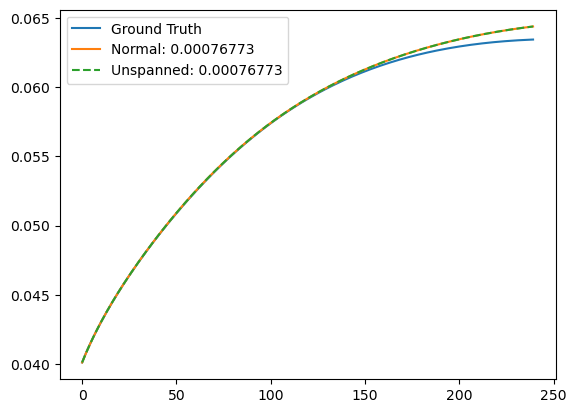

In [43]:
def rmse(act, pred, axis=False):
    if type(axis) == int:
        return np.sqrt(np.mean(np.square(act - pred), axis=axis))
    else:
        return np.sqrt(np.mean(np.square(act - pred)))
def extrapolate_mats():
    dh = DataHolder(dl=dl, unspanned=False)
    acm_pred = ACM(dh = dh, estimate_mu=True, atsm_max_mat=240).atsm.yields_fitted.values
    acm_pred_us = ACM(dh = dh, estimate_mu=True, atsm_max_mat=240).atsm.yields_fitted.values
    df_yields_wide = dh.new_df_yields(max_maturity=240)[:-1]
    axis = 0
    pred = np.mean(acm_pred, axis=axis)
    pred_us = np.mean(acm_pred_us, axis=axis)
    actual = np.mean(df_yields_wide.values, axis=axis)
    plt.plot(actual, label='Ground Truth')
    plt.plot(pred,label=f"Normal: {rmse(df_yields_wide, acm_pred_us):.8f}")
    plt.plot(pred_us, label=f"Unspanned: {rmse(df_yields_wide, acm_pred):.8f}", linestyle='--')
    plt.legend()

extrapolate_mats()
    

t_start: 2009-12




MODEL: s5pc Forecast Length 1 for 24 maturity: DM Statistic = 1.8721621824292825, P-value = 0.031932243004460306
MODEL: us5pc Forecast Length 1 for 24 maturity: DM Statistic = 3.4319349892320155, P-value = 0.0004239131096616843
MODEL: us5pc Forecast Length 2 for 24 maturity: DM Statistic = 2.088966760676526, P-value = 0.01951941847064941


MODEL: s5pc Forecast Length 1 for 60 maturity: DM Statistic = 4.288322572997204, P-value = 1.9528460302170112e-05
MODEL: s5pc Forecast Length 2 for 60 maturity: DM Statistic = 3.4366464969918904, P-value = 0.00041732182326361826
MODEL: s5pc Forecast Length 3 for 60 maturity: DM Statistic = 2.6186601336279867, P-value = 0.005041890415267887
MODEL: s5pc Forecast Length 4 for 60 maturity: DM Statistic = 1.8244984488467515, P-value = 0.035407924871654506
MODEL: us5pc Forecast Length 1 for 60 maturity: DM Statistic = 4.6271923129137225, P-value = 5.135894750088712e-06
MODEL: us5pc Forecast Length 2 for 60 maturity: DM Statistic = 4.11

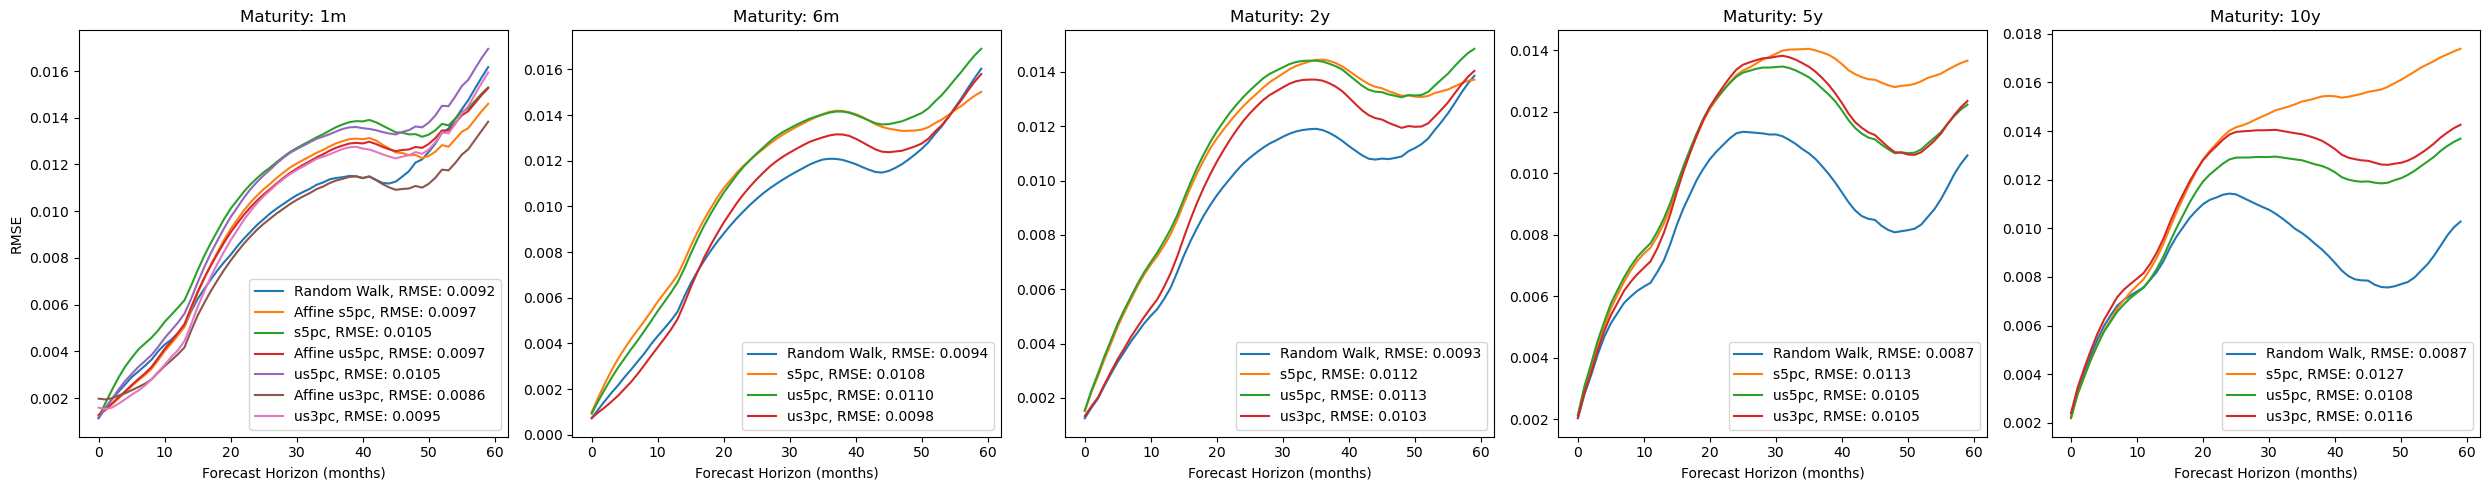

<Figure size 640x480 with 0 Axes>

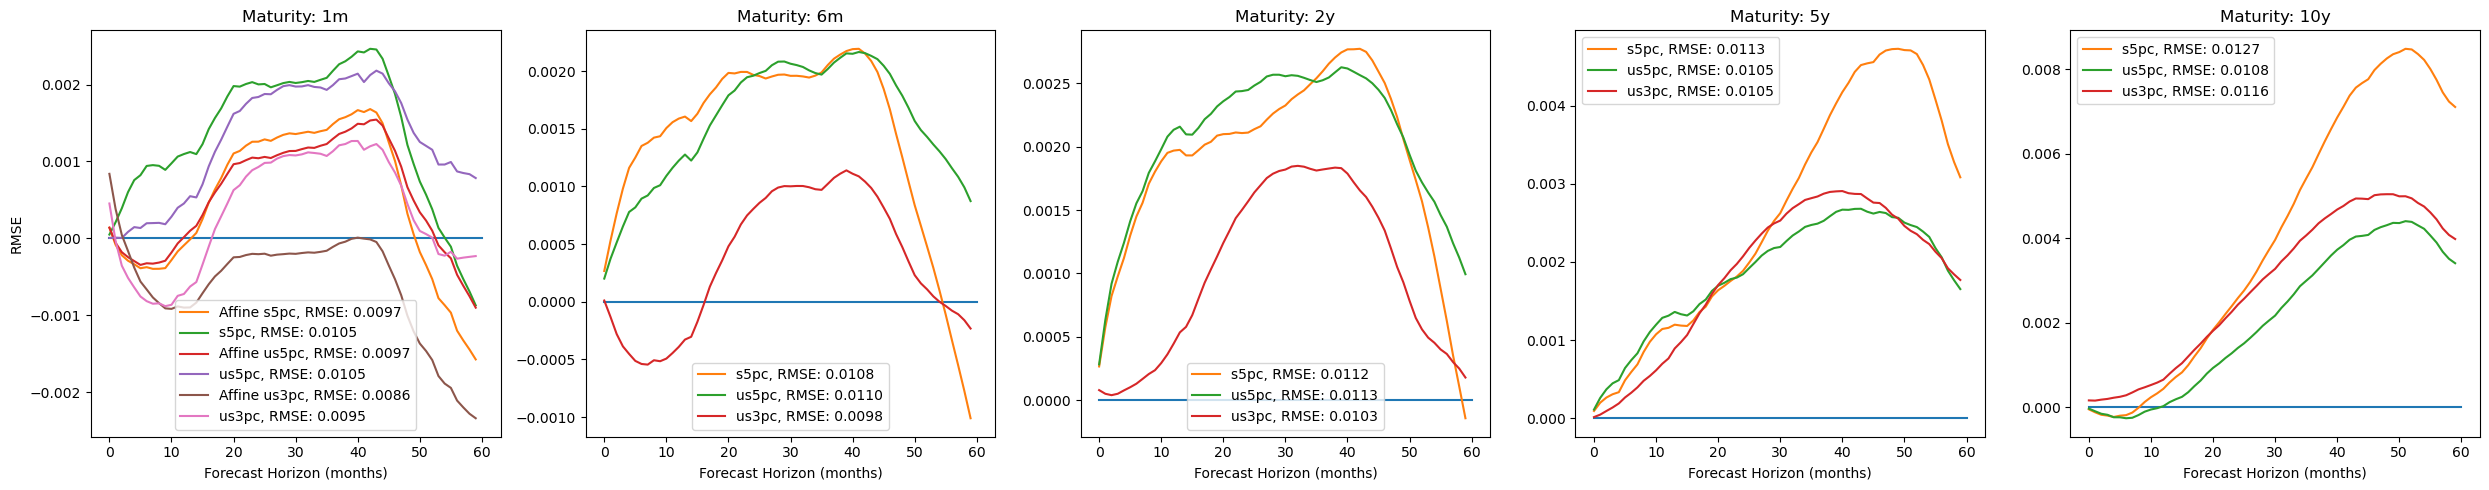

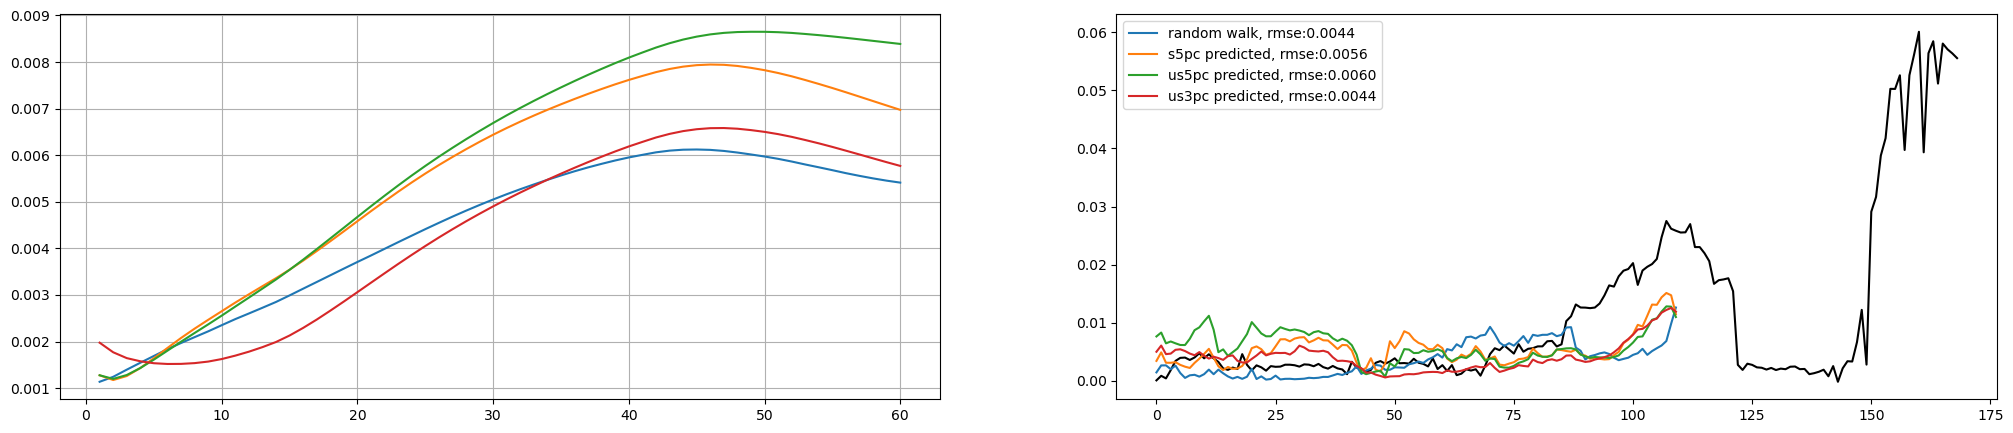

NameError: name 'maturity_idx' is not defined

In [44]:

def forecast( s=1,t_start = False, end_date='2011-12', big_plot=False, big_AFSR_plot=False):



    dh=DataHolder(end_date=end_date, dl=dl)
    df_yields = dh.df_yields

    print(f"t_start: {df_yields.index[t_start-1]}")
    T_pred = len(df_yields)-t_start-s
    N = df_yields.shape[1]
    models = ['s5pc', 'us5pc', 'us3pc']
    n_models = len(models)
    pred_matrix = np.zeros((n_models, len(df_yields)-t_start-s,s))
    rw_matrix = np.zeros((len(df_yields)-t_start-s,s))
    actual_matrix = np.zeros((len(df_yields)-t_start-s,s))
    actual_fsr_matrix = np.zeros((len(df_yields)-t_start-s,s))


    forecast_tensor = np.zeros((n_models,T_pred, s, N))# INDEX: N_models, T, S, N_maturity
    actual_tensor = np.zeros((T_pred, s, N))
    rw_tensor = actual_tensor.copy() 
    for i, conf in enumerate(models):
        if conf == 's5pc':
            unspanned = False
            n_components = 5
            est_mu = False
        elif conf ==  'us5pc':
            unspanned = True
            n_components = 5
            est_mu = True
        elif conf == 'us3pc':
            unspanned = True
            n_components = 3
            est_mu = True
        else:
            print("Model not specified")
            break


        
        for t in range(t_start, t_start + T_pred):
            dh = DataHolder(trim=t,dl=dl, unspanned=unspanned, n_components=n_components, end_date=end_date)
            acm = ACM(dh=dh, estimate_mu=est_mu)


            # AFSR PREDICTIN
            pred_AFSR = acm.atsm.yields_fitted_rf.iloc[-1, :s].values
            rw = [df_yields.iloc[t-2,0]]*s
            actual_AFSR = df_yields.iloc[t-1:t+s-1,0].expanding().mean().values
            actual_FSR = df_yields.iloc[t-1:t+s-1,0].values
            
            pred_matrix[i,t-t_start]=pred_AFSR
            rw_matrix[t-t_start]=rw
            actual_matrix[t-t_start]=actual_AFSR
            actual_fsr_matrix[t-t_start] = actual_FSR 



            
            # YIELD CURVE PREDICTION
            X_pred = acm.step1.predict_X(s)
            pred_yield = -(acm.atsm.A + X_pred@acm.atsm.B) / dh.maturities_y
            rw = [df_yields.iloc[t-2]]*s
            actual = df_yields.iloc[t-1:t+s-1]

            forecast_tensor[i, t-t_start]=pred_yield
            rw_tensor[t-t_start]=rw
            actual_tensor[t-t_start] = actual

    indices = [0, 5, 23, 59, 119]  # specific maturities of interest
    plt.figure(figsize=(25, 5))  # Adjust the figure size as necessary
    # ======================================  VAR Forecast  ======================================
    from scipy.stats import t as t_dist
    def diebold_mariano_test(errors1, errors2):
        diff = errors1**2 - errors2**2
        
        dbar = np.mean(diff)
        var_d = np.var(diff, ddof=1)
        T = len(diff)
        DM_stat = dbar / np.sqrt(var_d / T)
        p_value = t_dist.cdf(-np.abs(DM_stat), df=T-1)
        return DM_stat, p_value, dbar

    for i, idx in enumerate(indices):
        ax = plt.subplot(1, len(indices), i + 1)  # 1 row, N columns, i-th subplot
        
        

        # Compute RMSE for the random walk as a baseline comparison
        rmse_rw = rmse(act=actual_tensor[:, :, idx], pred=rw_tensor[:, :, idx], axis=0)
        ax.plot(rmse_rw, label=f'Random Walk, RMSE: {np.mean(rmse_rw):.4f}')

        # Compute and plot RMSE for each model
        for j, model_name in enumerate(models):
            if idx == 0: 
                rmse_pred = rmse(act=actual_tensor[:, :, idx], pred=pred_matrix[j], axis=0)
                ax.plot(rmse_pred, label=f'Affine {model_name}, RMSE: {np.mean(rmse_pred):.4f}')
            rmse_pred = rmse(act=actual_tensor[:, :, idx], pred=forecast_tensor[j, :, :, idx], axis=0)
            ax.plot(rmse_pred, label=f'{model_name}, RMSE: {np.mean(rmse_pred):.4f}')
            for s_idx in range(s):
                dm_stat, p_value, dbar = diebold_mariano_test(rw_tensor[:, s_idx, idx], forecast_tensor[j,:, s_idx, idx])
                if p_value <= 0.05 and dbar >0:
                    print(f"MODEL: {model_name} Forecast Length {s_idx+1} for {idx+1} maturity: DM Statistic = {dm_stat}, P-value = {p_value}")
        print("\n")
        # Set plot titles and labels
        maturity_label = f"{(idx + 1)//12}y" if idx >= 11 else f"{idx + 1}m"
        ax.set_title(f"Maturity: {maturity_label}")
        ax.legend()
        ax.set_xlabel('Forecast Horizon (months)')
        if i == 0:
            ax.set_ylabel('RMSE')
    plt.tight_layout()
    plt.show()
    # ==================================================================================================================
    plt.suptitle("relative rmse compared to rw")
    plt.figure(figsize=(25, 5))  # Adjust the figure size as necessary
    for i, idx in enumerate(indices):
        ax = plt.subplot(1, len(indices), i + 1)  # 1 row, N columns, i-th subplot
        ax.plot([0,s], [0,0])

        # Compute RMSE for the random walk as a baseline comparison
        rmse_rw = rmse(act=actual_tensor[:, :, idx], pred=rw_tensor[:, :, idx], axis=0)
        #ax.plot(rmse_rw, label=f'Random Walk, RMSE: {np.mean(rmse_rw):.4f}')

        # Compute and plot RMSE for each model
        for j, model_name in enumerate(models):
            if idx == 0: 
                rmse_pred = rmse(act=actual_tensor[:, :, idx], pred=pred_matrix[j], axis=0)
                ax.plot(rmse_pred-rmse_rw, label=f'Affine {model_name}, RMSE: {np.mean(rmse_pred):.4f}')
            rmse_pred = rmse(act=actual_tensor[:, :, idx], pred=forecast_tensor[j, :, :, idx], axis=0)
            ax.plot(rmse_pred-rmse_rw, label=f'{model_name}, RMSE: {np.mean(rmse_pred):.4f}')
            
        # Set plot titles and labels
        maturity_label = f"{(idx + 1)//12}y" if idx >= 11 else f"{idx + 1}m"
        ax.set_title(f"Maturity: {maturity_label}")
        ax.legend()
        ax.set_xlabel('Forecast Horizon (months)')
        if i == 0:
            ax.set_ylabel('RMSE')
    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(25, 5))
    rmse_rw = rmse(act=actual_matrix, pred=rw_matrix, axis=0)
    rmse_rw_ot = np.sqrt(np.mean(np.square(actual_matrix-rw_matrix), axis=1))
    ax1 = plt.subplot(1, 2, 1)
    ax1.plot(np.arange(1,s+1),rmse_rw, label=f'random walk, rmse:{np.mean(rmse_rw):.4f}')
   
    ax2 = plt.subplot(1, 2, 2)
    ax2.plot(df_yields.iloc[t_start:-1,0].values, c='black')
    ax2.plot(rmse_rw_ot, label=f'random walk, rmse:{np.mean(rmse_rw):.4f}')
    for i, m in enumerate(models):
        
        rmse_pred = rmse(act=actual_matrix, pred=pred_matrix[i], axis=0)
        rmse_pred_ot = rmse(act=actual_matrix, pred=pred_matrix[i], axis=1)
        ax1.plot(np.arange(1,s+1),rmse_pred, label=f'{m} predicted, rmse:{np.mean(rmse_pred):.4f}')
        ax2.plot(rmse_pred_ot, label=f'{m} predicted, rmse:{np.mean(rmse_pred):.4f}')
    ax1.grid()
    ax2.grid()
    plt.legend()
    plt.grid()
    plt.show()

    #plt.plot(forecast_tensor[0,:,1])
    #plt.plot(actual_tensor[0,:,1])
    # plt.figure(figsize=(40, 20), dpi=80)
    # maturity_idx = 1
    if big_plot:
        for t in range(0,forecast_tensor.shape[0],6):
            
            plt.plot(np.arange(s)+t, actual_tensor[t,:,maturity_idx], c='red')
            plt.plot(np.arange(s)+t, forecast_tensor[t,:,maturity_idx], c='blue',linestyle='--')
            plt.plot(np.arange(s)+t, rw_tensor[t,:,maturity_idx], c='purple',linestyle='--')
        plt.plot(np.arange(df_yields.shape[0]-1)-t_start+1,df_yields.iloc[:-1,maturity_idx].values, c='black', linestyle='--')
        plt.plot(np.arange(df_yields.shape[0]-1-s )+s+1-t_start,df_yields.iloc[:(-1-s),maturity_idx].expanding().mean().values, c='black')
        actual_dates = df_yields.index.to_timestamp()[:-1]
        plt.xticks(np.arange(-t_start, len(df_yields.iloc[:(-1-s),maturity_idx])+s-t_start, 12), [date.strftime('%Y-%m-%d') for date in actual_dates[::12]])  # Adjust stride as necessary)
        plt.grid()
        plt.xticks(rotation=45)

    # rmse_pred = np.sqrt(np.mean(np.square(actual_matrix-pred_matrix), axis=0))
    # rmse_rw = np.sqrt(np.mean(np.square(actual_matrix-rw_matrix), axis=0))
    # rmse_pred_ot = np.sqrt(np.mean(np.square(actual_matrix-pred_matrix), axis=1))
    # rmse_rw_ot = np.sqrt(np.mean(np.square(actual_matrix-rw_matrix), axis=1))
    # if big_AFSR_plot:
    #     for t in range(0,pred_matrix.shape[0],6):
    #             #print(t)
    #         plt.plot(np.arange(s)+t, actual_matrix[t], c='red')
    #         plt.plot(np.arange(s)+t, pred_matrix[t], c='blue',linestyle='--')
    #         plt.plot(np.arange(s)+t, rw_matrix[t], c='purple',linestyle='--')
    #         #plt.plot(np.arange(s)+t, actual_fsr_matrix[t])
    #     plt.plot(np.arange(len(df_yields.iloc[t_start:-1,0]))+1,df_yields.iloc[t_start:-1,0].values, c='black')
    #     plt.grid()
    #     plt.show()
    
    # plt.plot(np.arange(1,s+1),rmse_pred, label=f'predicted, rmse:{np.mean(rmse_pred):.4f}')
    # plt.plot(np.arange(1,s+1),rmse_rw, label=f'random walk, rmse:{np.mean(rmse_rw):.4f}')
    # plt.legend()
    # plt.grid()
    # plt.show()

    # plt.plot(df_yields.iloc[t_start:-1,0].values, c='black')
    # plt.plot(rmse_pred_ot, label=f'predicted, rmse:{np.mean(rmse_pred):.4f}')
    # plt.plot(rmse_rw_ot, label=f'random walk, rmse:{np.mean(rmse_rw):.4f}')
    # plt.legend()
    # plt.grid()
    # plt.show()


forecast(t_start=12*23+1, s=60, end_date='2025-12', big_plot=True)

In [ ]:
np.zeros((2,2,2))[0]


array([[0., 0.],
       [0., 0.]])

In [ ]:
def predict_AFSR(t_start, df_yields, us_data, s = 60, unspanned=False):
    
    print(f"t_start: {df_yields.index[t_start-1]}")
    for t in range(t_start, len(df_yields) - s):
        #
        scaler = StandardScaler()
        if unspanned:
            us_data_standard = scaler.fit_transform(us_data.iloc[:t].values).T

            acm = ACM(df_yields=df_yields.iloc[:t], n_components=5).estimate_ACM(estimate_mu=False, X_full_u=us_data_standard)
        else: 
            acm = ACM(df_yields=df_yields.iloc[:t]).estimate_ACM(estimate_mu=False)
        pred_AFSR = acm.atsm.yields_fitted_rf.iloc[-1, :s].values
        rw = [df_yields.iloc[t-2,0]]*s
        actual_AFSR = df_yields.iloc[t-1:t+s-1,0].expanding().mean().values
        actual_FSR = df_yields.iloc[t-1:t+s-1,0].values
        
        pred_matrix[t-t_start]=pred_AFSR
        rw_matrix[t-t_start]=rw
        actual_matrix[t-t_start]=actual_AFSR
        actual_fsr_matrix[t-t_start] = actual_FSR 
    

    rmse_pred = np.sqrt(np.mean(np.square(actual_matrix-pred_matrix), axis=0))
    rmse_rw = np.sqrt(np.mean(np.square(actual_matrix-rw_matrix), axis=0))
    rmse_pred_ot = np.sqrt(np.mean(np.square(actual_matrix-pred_matrix), axis=1))
    rmse_rw_ot = np.sqrt(np.mean(np.square(actual_matrix-rw_matrix), axis=1))
    
    for t in range(0,pred_matrix.shape[0],6):
        #print(t)
        plt.plot(np.arange(s)+t, actual_matrix[t], c='red')
        plt.plot(np.arange(s)+t, pred_matrix[t], c='blue',linestyle='--')
        plt.plot(np.arange(s)+t, rw_matrix[t], c='purple',linestyle='--')
        #plt.plot(np.arange(s)+t, actual_fsr_matrix[t])
    plt.plot(df_yields.iloc[t_start:-1,0].values, c='black')
    plt.show()
    
    plt.plot(np.arange(1,s+1),rmse_pred, label=f'predicted, rmse:{np.mean(rmse_pred):.4f}')
    plt.plot(np.arange(1,s+1),rmse_rw, label=f'random walk, rmse:{np.mean(rmse_rw):.4f}')
    plt.legend()
    plt.grid()
    plt.show()

    plt.plot(df_yields.iloc[t_start:-1,0].values, c='black')
    plt.plot(rmse_pred_ot, label=f'predicted, rmse:{np.mean(rmse_pred):.4f}')
    plt.plot(rmse_rw_ot, label=f'random walk, rmse:{np.mean(rmse_rw):.4f}')
    plt.legend()
    plt.grid()
    plt.show()
    
    
    


paper_t_start = 12*5+1
predict_AFSR(t_start=12*7, df_yields=df_yields,us_data=us_data, unspanned=True, s=60)


NameError: name 'df_yields' is not defined

In [ ]:
X = np.hstack((np.ones((len(df_yields[:-1]),1)),df_yields['1m'].iloc[:-1].values.reshape(-1,1)))
OLS(df_yields['1m'].iloc[1:].values, X).fit().summary()

In [ ]:
model = LinearRegression()
X= df_yields['1m'].iloc[:-1].values.reshape(-1,1)
plt.plot(model.fit(y=df_yields['1m'].iloc[1:], X=X).predict(X=X))
plt.plot(df_yields['1m'].iloc[1:].values)